### Cargar librerias

In [9]:
# Importar TensorFlow
import tensorflow as tf

# Importar componentes de Keras para crear y entrenar el modelo
from keras import datasets, layers, models

# Importar Matplotlib para visualizar las imágenes
import matplotlib.pyplot as plt


### Cargar dataset CIFAR-10

In [10]:
# Cargar el conjunto de datos CIFAR-10 desde Keras
# x = images, y = labels
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Verificar las dimensiones de los datos cargados
print("Forma de las imágenes de entrenamiento:", train_images.shape)
print("Forma de las etiquetas de entrenamiento:", train_labels.shape)
print("Forma de las imágenes de prueba:", test_images.shape)
print("Forma de las etiquetas de prueba:", test_labels.shape)


Forma de las imágenes de entrenamiento: (50000, 32, 32, 3)
Forma de las etiquetas de entrenamiento: (50000, 1)
Forma de las imágenes de prueba: (10000, 32, 32, 3)
Forma de las etiquetas de prueba: (10000, 1)


In [11]:
# Mostrar de nuevo la forma (shape) del conjunto de entrenamiento para confirmar dimensiones
print("Shape de train_images:", train_images.shape)
print("Shape de train_labels:", train_labels.shape)

Shape de train_images: (50000, 32, 32, 3)
Shape de train_labels: (50000, 1)


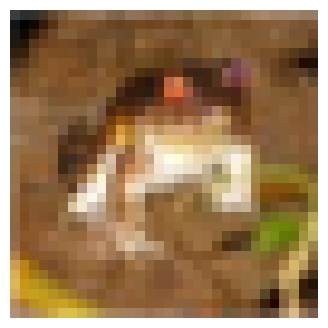

Primera etiqueta: 6


In [12]:
# Visualizar la primera imagen del conjunto de entrenamiento
plt.figure(figsize=(4, 4))
plt.imshow(train_images[0])
plt.axis("off")
plt.show()

# Mostrar la etiqueta numérica asociada a la imagen mostrada
print("Primera etiqueta:", train_labels[0][0])

In [13]:
# Definir el nombre de cada clase del dataset CIFAR-10
clases = [
    "avion",
    "automovil",
    "pajaro",
    "gato",
    "ciervo",
    "perro",
    "rana",
    "caballo",
    "barco",
    "camión o bus"
]

# Imprimir el listado de clases para ver la correspondencia índice -> nombre
print(clases)

['avion', 'automovil', 'pajaro', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camión o bus']


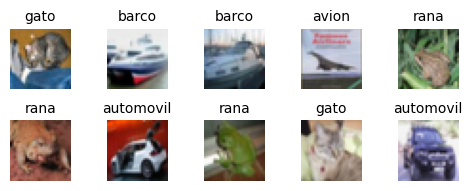

In [14]:
# Importar range original para evitar conflictos con redefiniciones previas
from builtins import range as _range

# Preparar una figura temporal y luego cerrarla (mantenido tal como está en tu flujo actual)
fig, axes = plt.subplots(6, 5, figsize=(12, 14))
axes = axes.ravel()
plt.close(fig)

# Crear la figura final para visualizar un subconjunto de imágenes de prueba
fig, axes = plt.subplots(2, 5, figsize=(5, 2))
axes = axes.ravel()

# Forzar un rango de 10 iteraciones para llenar la cuadrícula 2x5
range = lambda n: _range(10)
for i in range(30):
    axes[i].imshow(test_images[i])
    axes[i].set_title(clases[test_labels[i][0]], fontsize=10)
    axes[i].axis("off")

# Ajustar espacios y mostrar la figura
plt.tight_layout()
plt.show()

In [15]:
# Inspeccionar los valores de píxeles de la primera imagen antes/después del preprocesamiento
train_images[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

In [16]:
# Normalizar los valores de los píxeles para que estén en el rango [0, 1]
# Esto se hace dividiendo entre 255.0, ya que los valores de píxel originales están en el rango [0, 255]
train_images, test_images = train_images / 255.0, test_images / 255.0

train_images[0]

array([[[0.23137255, 0.24313725, 0.24705882],
        [0.16862745, 0.18039216, 0.17647059],
        [0.19607843, 0.18823529, 0.16862745],
        ...,
        [0.61960784, 0.51764706, 0.42352941],
        [0.59607843, 0.49019608, 0.4       ],
        [0.58039216, 0.48627451, 0.40392157]],

       [[0.0627451 , 0.07843137, 0.07843137],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509804, 0.21568627],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117647, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215686, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941176, 0.19607843],
        [0.47058824, 0.32941176, 0.19607843],
        [0.42745098, 0.28627451, 0.16470588]],

       ...,

       [[0.81568627, 0.66666667, 0.37647059],
        [0.78823529, 0.6       , 0.13333333],
        [0.77647059, 0

In [17]:
# Importar NumPy para operaciones sobre arreglos
import numpy as np

# Convertir etiquetas a un vector 1D para facilitar su análisis
labels_train_np = np.array(train_labels).reshape(-1)
unique_values = np.unique(labels_train_np)

# Mostrar los valores únicos presentes en las etiquetas de entrenamiento
print("Valores únicos en train_labels:", unique_values)

Valores únicos en train_labels: [0 1 2 3 4 5 6 7 8 9]


### Construccion de Red Convolucional

In [18]:
# Parte convolucional del modelo
conv_model = models.Sequential([
    # Usar la capa Input para definir la forma de entrada
    layers.Input(shape=train_images.shape[1:]),  # (32, 32, 3)

    # Primera capa convolucional: 32 filtros de tamaño 3x3, función de activación ReLU
    layers.Conv2D(32, (3, 3), activation="relu"),

    # Primera capa de max pooling: reduce la dimensionalidad a la mitad, tomando el valor máximo de cada bloque 2x2
    layers.MaxPooling2D((2, 2)),

    # Segunda capa convolucional: 64 filtros de tamaño 3x3, función de activación ReLU
    layers.Conv2D(64, (3, 3), activation="relu"),

    # Segunda capa de max pooling: reduce nuevamente la dimensionalidad
    layers.MaxPooling2D((2, 2)),

    # Tercera capa convolucional: 64 filtros de tamaño 3x3, función de activación ReLU
    layers.Conv2D(64, (3, 3), activation="relu"),
])

conv_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

NOTA: Notese que la shape del primer conv2d es 30x30 no 32x32, esto es porque no estamos usando valid-padding y por ende estamos perdiendo la primera y ultima fila en la capa de convolución.

### Añadir Capas densas y de Salida

In [19]:
# Añadir la parte densa al modelo convolucional existente
conv_model.add(layers.Flatten())
conv_model.add(layers.Dense(64, activation="relu"))
conv_model.add(layers.Dense(10, activation="softmax"))

# Verificar la arquitectura final
conv_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

### Compilar y Entrenar

In [21]:
# Compilar el modelo:
# - Usamos softmax en la salida (10 clases mutuamente excluyentes) y etiquetas enteras,
#   por eso la pérdida correcta es sparse_categorical_crossentropy.
# - Si fuera clasificación binaria con sigmoid, usaríamos binary_crossentropy.
# - Si fuera regresión, usaríamos una pérdida como mse o mae.
conv_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]  # En regresión, métricas comunes: mae o rmse.
)

# Entrenar con 50 épocas y validación usando el 15% del set de entrenamiento
history = conv_model.fit(
    train_images,
    train_labels,
    epochs=50,
    validation_split=0.15,
    verbose=1
)

# Evaluar en el conjunto de prueba
test_loss, test_accuracy = conv_model.evaluate(test_images, test_labels, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")


Epoch 1/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.4667 - loss: 1.4784 - val_accuracy: 0.5500 - val_loss: 1.2554
Epoch 2/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6016 - loss: 1.1267 - val_accuracy: 0.6339 - val_loss: 1.0621
Epoch 3/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6518 - loss: 0.9972 - val_accuracy: 0.6531 - val_loss: 1.0105
Epoch 4/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6821 - loss: 0.9126 - val_accuracy: 0.6432 - val_loss: 1.0477
Epoch 5/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7050 - loss: 0.8483 - val_accuracy: 0.6763 - val_loss: 0.9444
Epoch 6/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7250 - loss: 0.7900 - val_accuracy: 0.6784 - val_loss: 0.9406
Epoch 7/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7439 - loss: 0.7386 - val_accuracy: 0.6897 - val_loss: 0.9246
Epoch 8/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7603 - loss: 0.6904 -

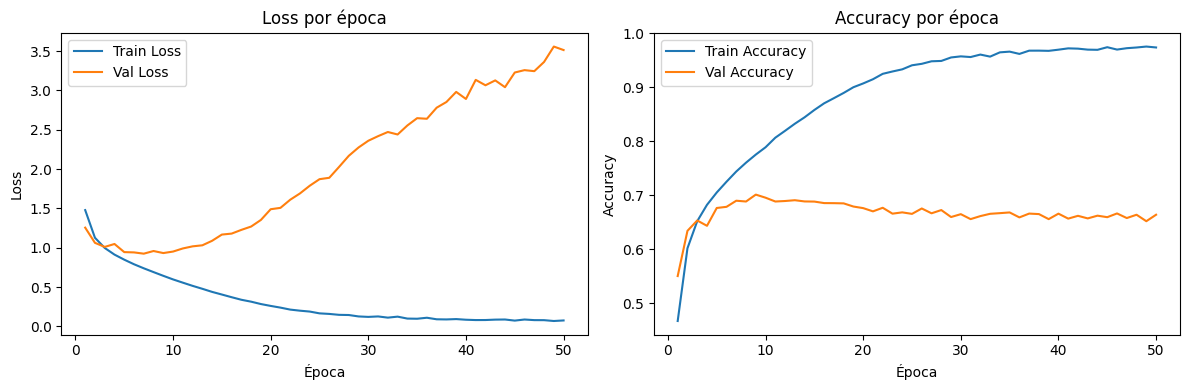

In [23]:
# Graficar pérdida y exactitud (entrenamiento vs validación)
hist = history.history
epochs = [idx + 1 for idx, _ in enumerate(hist["loss"])]

plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, hist["loss"], label="Loss")
plt.plot(epochs, hist["val_loss"], label="Val Loss")
plt.title("Loss por época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, hist["accuracy"], label="Accuracy")
plt.plot(epochs, hist["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy por época")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

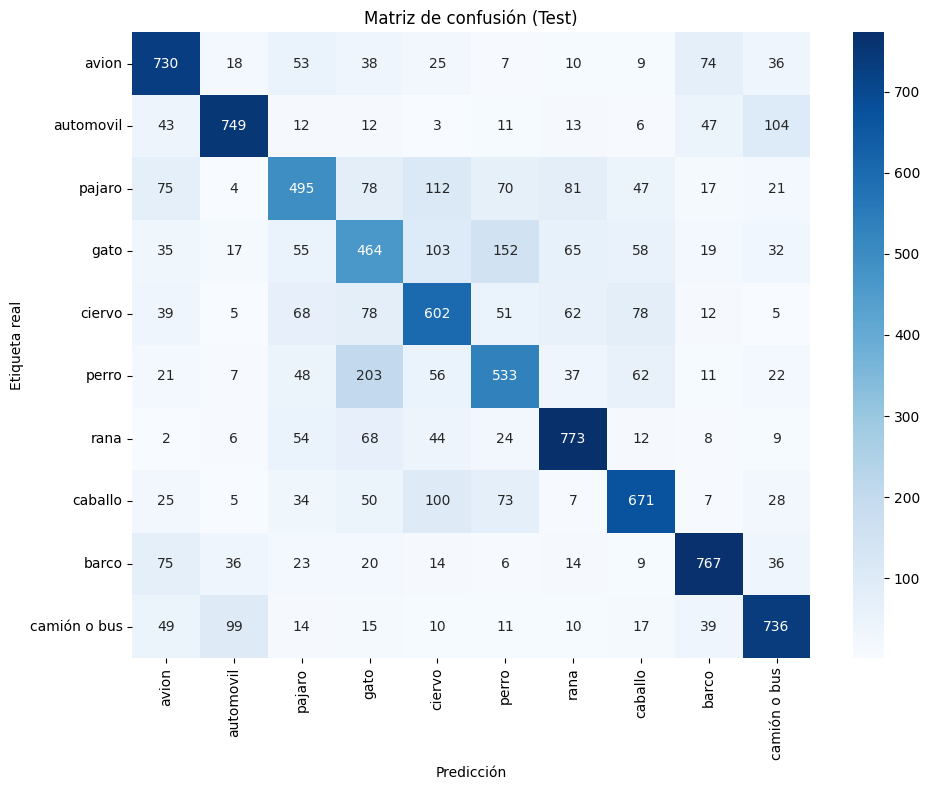

=== Reporte de clasificación ===
              precision    recall  f1-score   support

       avion     0.6673    0.7300    0.6972      1000
   automovil     0.7918    0.7490    0.7698      1000
      pajaro     0.5783    0.4950    0.5334      1000
        gato     0.4522    0.4640    0.4580      1000
      ciervo     0.5631    0.6020    0.5819      1000
       perro     0.5682    0.5330    0.5501      1000
        rana     0.7211    0.7730    0.7461      1000
     caballo     0.6925    0.6710    0.6816      1000
       barco     0.7662    0.7670    0.7666      1000
camión o bus     0.7153    0.7360    0.7255      1000

    accuracy                         0.6520     10000
   macro avg     0.6516    0.6520    0.6510     10000
weighted avg     0.6516    0.6520    0.6510     10000

Accuracy:         0.6520
Precision macro:  0.6516
Recall macro:     0.6520
F1 macro:         0.6510
Precision weight: 0.6516
Recall weight:    0.6520
F1 weight:        0.6510


In [24]:
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_recall_fscore_support,
)

# Predicciones del modelo sobre test
y_true = test_labels.reshape(-1)
y_pred = conv_model.predict(test_images, verbose=0).argmax(axis=1)

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=clases,
    yticklabels=clases
)
plt.title("Matriz de confusión (Test)")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.tight_layout()
plt.show()

# Métricas de clasificación
print("=== Reporte de clasificación ===")
print(classification_report(y_true, y_pred, target_names=clases, digits=4))

acc = accuracy_score(y_true, y_pred)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro"
)
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted"
)

print(f"Accuracy:         {acc:.4f}")
print(f"Precision macro:  {prec_macro:.4f}")
print(f"Recall macro:     {rec_macro:.4f}")
print(f"F1 macro:         {f1_macro:.4f}")
print(f"Precision weight: {prec_weighted:.4f}")
print(f"Recall weight:    {rec_weighted:.4f}")
print(f"F1 weight:        {f1_weighted:.4f}")

121687/121687 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


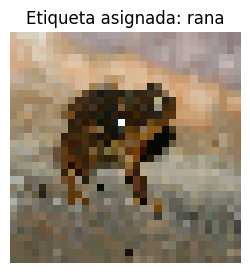

Etiqueta asignada por el modelo: rana
Probabilidad de 'rana': 1.0000

Probabilidades por clase:
avion         : 0.0000
automovil     : 0.0000
pajaro        : 0.0000
gato          : 0.0000
ciervo        : 0.0000
perro         : 0.0000
rana          : 1.0000
caballo       : 0.0000
barco         : 0.0000
camión o bus  : 0.0000


In [ ]:
# Cargar y preprocesar la imagen de prueba directamente desde URL
img_url = "https://cdn.prod.website-files.com/64df6dd37ac6a0dbb9d03cb3/6597f2646581043618e42856_Instituto-Humboldt-rana-derecha.jpg"
img_path = tf.keras.utils.get_file(fname="rana_test.jpg", origin=img_url)

# IMPORTANTE: la imagen de entrada debe preprocesarse igual que en el entrenamiento
# (mismo tamaño y misma normalización /255.0) para obtener mejor precisión.
img = tf.keras.utils.load_img(img_path, target_size=(32, 32))
img_array = tf.keras.utils.img_to_array(img) / 255.0
img_input = np.expand_dims(img_array, axis=0)  # shape: (1, 32, 32, 3)

# Predicción
probs = conv_model.predict(img_input, verbose=0)[0]
pred_idx = int(np.argmax(probs))
pred_label = clases[pred_idx]

# Mostrar imagen y etiqueta asignada
plt.figure(figsize=(3, 3))
plt.imshow(img_array)
plt.title(f"Etiqueta asignada: {pred_label}")
plt.axis("off")
plt.show()

print(f"Etiqueta asignada por el modelo: {pred_label}")
print(f"Probabilidad de 'rana': {probs[clases.index('rana')]:.4f}\n")

print("Probabilidades por clase:")
for clase, p in zip(clases, probs):
    print(f"{clase:14s}: {p:.4f}")

In [27]:
# Montar Google Drive en Colab
from google.colab import drive
import os

drive.mount("/content/drive")

# Definir la carpeta destino y crearla si no existe
save_dir = "/content/drive/MyDrive/Ciencia de Datos"
os.makedirs(save_dir, exist_ok=True)

# Guardar el modelo entrenado en formato Keras dentro de Google Drive
model_path = f"{save_dir}/detector.keras"
conv_model.save(model_path)
print(f"Modelo guardado en: {model_path}")

Mounted at /content/drive
Modelo guardado en: /content/drive/MyDrive/Ciencia de Datos/detector.keras


In [28]:
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {getattr(tf.keras, '__version__', 'No disponible')}")

TensorFlow version: 2.19.0
Keras version: 3.13.2
